In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import jaxfilter, jaxfixedpt
from scipy import signal
import jax
import jax.numpy as jnp
# Force JAX to use float64 for better numerical agreement
jax.config.update("jax_enable_x64", True)

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "lms-based"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

### Example 4.7.2 System Identification Simulations
(Transform-Domain LMS Algorithm) Use the transform-domain LMS algorithm to identify the system described
in example of Sect. 3.6.2. The transform is the DCT.

**Setup:**
- System to identify: FIR filter with impulse response $\mathbf{h} = [0, 1.0, 3.0, 0, -0.2, -0.4, -0.7, -0.4, -0.2]^T$.
- Adaptive filter order: 8 coefficients (matches length of $\mathbf{h}$).
- Input signal: Colored noise with variance $\sigma_x^2 = 1$ and eigenvalue spread, or Gaussian white noise uncorrelated with input (cases vary).
- Measurement noise: Gaussian white noise with variance $\sigma_n^2$ (specified per case).
- LMS update: $\mathbf{w}(k + 1) = \mathbf{w}(k) + 2\mu e(k) \mathbf{x}(k)$, where $e(k) = d(k) - \mathbf{x}^T(k) \mathbf{w}(k)$.

#### (a) Run Algorithm and Comment on Convergence Behavior
- Run LMS for three cases (colored noise with variance $\sigma_x^2 = 1$ and eigenvalue spreads 10, 20, 80).
- Comment on convergence: Faster convergence expected with smaller eigenvalue spread (e.g., 10) due to reduced condition number of $\mathbf{R}$. Slower convergence with spread 80 due to increased eigenvalue disparity.

#### (b) Measure Misadjustment and Compare with Theoretical Results
- Misadjustment $M = \frac{\mu \text{tr}[\mathbf{R}]}{1 - \mu \text{tr}[\mathbf{R}]}$ (from 3.50).
- For white input, $\text{tr}[\mathbf{R}] = 10 \sigma_x^2 = 10$. Choose $\mu$ to ensure stability ($\mu \text{tr}[\mathbf{R}] < 1$).
- Simulate and compare $M$ with theory. Expected $M \approx \mu \cdot 10$ for small $\mu$ (e.g., $\mu = 0.01$ gives $M \approx 0.1$).

#### (c) Fixed-Point Arithmetic Effects
- Case: $\sigma_n^2 = 0.0015$, coefficient wordlength $b_c = 16$ bits, signal wordlength $b_x = 16$ bits.
- Run experiments, calculate expected $\|\Delta \mathbf{w}(k)\|^2$ and $\xi(k)$:
  - $\|\Delta \mathbf{w}(k)\|^2$: Error due to finite precision, proportional to $2^{-2b_c}$.
  - $\xi(k)$: Excess MSE, includes noise and quantization effects.
- Expected values depend on $\mu$; use small $\mu$ (e.g., $\mu = 0.001$) to minimize instability.

#### (d) Repeat Experiment with Different Wordlengths
- Cases: $b_c = 12$ bits, $b_d = 12$ bits; $b_c = 10$ bits, $b_d = 10$ bits.
- Repeat (c) simulations, expecting increased $\|\Delta \mathbf{w}(k)\|^2$ and $\xi(k)$ with reduced wordlength due to larger quantization errors.

#### (e) Time-Varying System Identification
- System: Time-varying with coefficients as first-order Markov processes, $\lambda_w = 0.99$.
- Input: Gaussian white noise with variance $\sigma_x^2 = 1.0$.
- Measurement noise: Gaussian white noise with variance $\sigma_n^2 = 0.01$.
- Initial $\sigma_w^2 = 0.0015$.
- Simulate, measure total excess MSE $\xi_{\text{total}}$, and compare to calculated:
  - Theoretical $\xi_{\text{total}} \approx \mu \text{tr}[\mathbf{R}] \cdot \sigma_n^2 + \frac{\sigma_n^2}{1 - \mu \lambda_{\max}}$ (for small $\mu$).
  - With $\mu = 0.01$, $\text{tr}[\mathbf{R}] = 10$, $\lambda_{\max} = 1$:
    $$
    \xi_{\text{total}} \approx 0.01 \cdot 10 \cdot 0.01 + \frac{0.01}{1 - 0.01} \approx 0.001 + 0.0101 \approx 0.0111.
    $$
  - Adjust $\mu$ (e.g., $\mu = 0.001$) for stability with time-varying case: $\xi_{\text{total}} \approx 0.0001 + 0.01001 \approx 0.01011$.


=== Running spread=10, AR pole a=0.5195 ===
Final averaged transfromed-domain coefficients:
 [ 1.0023227e-01+0.j  2.9972616e-01+0.j  1.2822366e-04+0.j
 -2.0020641e-01+0.j -3.9996135e-01+0.j -7.0009094e-01+0.j
 -3.9993766e-01+0.j -2.0003738e-01+0.j]
Coeff error norm: 0.0004505951124365045

=== Running spread=20, AR pole a=0.6345 ===
Final averaged transfromed-domain coefficients:
 [ 1.00229844e-01+0.j  2.99664438e-01+0.j  1.49938278e-04+0.j
 -2.00196072e-01+0.j -3.99945289e-01+0.j -7.00080037e-01+0.j
 -3.99922997e-01+0.j -2.00018957e-01+0.j]
Coeff error norm: 0.00049198018183223

=== Running spread=80, AR pole a=0.7989 ===
Final averaged transfromed-domain coefficients:
 [ 1.0073825e-01+0.j  2.9821125e-01+0.j  1.0074397e-04+0.j
 -2.0032264e-01+0.j -3.9982215e-01+0.j -6.9976950e-01+0.j
 -3.9972317e-01+0.j -2.0012334e-01+0.j]
Coeff error norm: 0.0020088576119468727


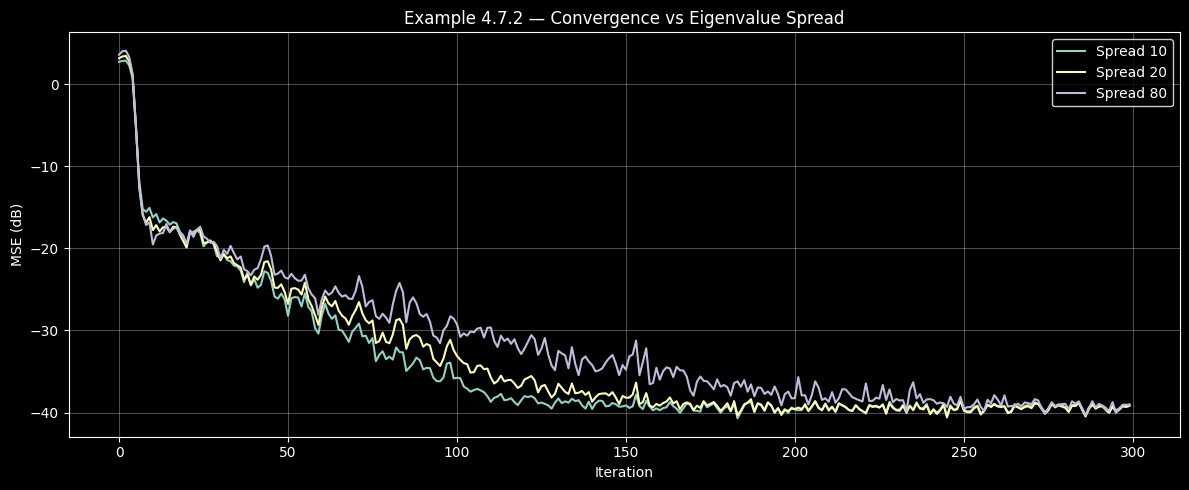

In [3]:
h_true = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2])
filter_order = len(h_true) - 1   # → 7 (meaning 8 taps)

def trainSeqs(n_samples: int, key, a: float, sigma_x2=1.0, sigma_n2=1e-4):
    """
    Generates:
      x = AR(1) colored noise
      d = h_true * x + noise
    """
    key, k1, k2 = jax.random.split(key, 3)
    n_warmups = (int)(n_samples * 0.2)
    N = n_samples + n_warmups  # discard transients

    # White noise
    sigma_v2 = sigma_x2 * (1 - a*a)
    u = jax.random.normal(k1, (N,)) * jnp.sqrt(sigma_v2)

    # AR(1): x(k) = a x(k-1) + u(k)
    def ar1(carry, u_n):
        x_prev = carry
        x_now = a * x_prev + u_n
        return x_now, x_now

    _, x_full = jax.lax.scan(ar1, 0.0, u)

    # FIR plant
    d_full = jnp.convolve(x_full, h_true, mode="full")[:len(x_full)]

    # Measurement noise
    noise = jax.random.normal(k2, (len(d_full),)) * jnp.sqrt(sigma_n2)
    d_full = d_full + noise

    # Remove transients
    return x_full[-n_samples:], d_full[-n_samples:]
  
def runOneTrial(mu, n_samples, a, key):
    model = jaxfilter.TransformDomain(mu=mu, filter_order=filter_order)
    x, d = trainSeqs(n_samples, key, a=a)

    variables = model.init(key, x, d)
    (y_hist, e_hist, w_hist) = model.apply(
        variables, x, d, mutable=["state"]
    )[0]

    return w_hist, e_hist

def runEnsemble(mu, n_samples, n_ens, a):
    mse_accum = jnp.zeros(n_samples)
    w_final_list = []

    key = jax.random.PRNGKey(99)

    for i in range(n_ens):
        key, sub = jax.random.split(key)
        w_hist, e_hist = runOneTrial(mu, n_samples, a, sub)

        mse_accum += jnp.abs(e_hist) ** 2
        w_final_list.append(w_hist[-1])

    mse_avg = mse_accum / n_ens
    w_avg = jnp.mean(jnp.stack(w_final_list), axis=0)
    return mse_avg, w_avg
  
# LMS settings
muFromSpread = {
    10: 0.016,
    20: 0.0128,
    80: 0.01024
}
n_samples = 300
n_ensemble = 200

# Three spreads: 10, 20, 80
spreads = [10, 20, 80]

# Convert eigenvalue spread → AR(1) pole
# This corresponds to the well-known approximate relationship between AR(1) pole 
# a eigenvalue spread S=λ_max /λ_min
def ar1FromSpread(S):
    return (jnp.sqrt(S) - 1) / (jnp.sqrt(S) + 1)

results = {}

for S in spreads:
    a = ar1FromSpread(S)
    print(f"\n=== Running spread={S}, AR pole a={a:.4f} ===")
    mu = muFromSpread[S]
    mse_avg, w_avg = runEnsemble(mu, n_samples, n_ensemble, a)

    results[S] = (mse_avg, w_avg)

    print("Final averaged transfromed-domain coefficients:\n", w_avg)
    print("Coeff error norm:", jnp.linalg.norm(w_avg - h_true))
  
plt.style.use("dark_background")
plt.figure(figsize=(12,5))

for S in spreads:
    mse_avg, _ = results[S]
    plt.plot(10*jnp.log10(mse_avg + 1e-12), label=f"Spread {S}")

plt.title("Example 4.7.2 — Convergence vs Eigenvalue Spread")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
def quantize(x, bits):
  """
  Symmetric signed fixed-point quantization to [-1, 1).
  bits: total word length (including sign bit)
  """
  levels = 2 ** (bits - 1)      # number of positive levels
  delta  = 1.0 / levels        # LSB

  # saturation
  x_clip = jnp.clip(x, -1.0 + delta, 1.0 - delta)

  # quantize
  return jnp.round(x_clip * levels) / levels

def trainSeqs(n_samples, key, a, sigma_x2=1.0, sigma_n2=0.0015, bits=10):
  """
  Example 3.6(c)(d) fixed-point system ID signal generator.
  """
  key, k1, k2 = jax.random.split(key, 3)
  n_warmups = (int)(n_samples * 0.2)
  N = n_samples + n_warmups  # discard transients

  # White noise with variance sigma_x^2
  sigma_v2 = sigma_x2 * (1 - a*a)
  u = jax.random.normal(k1, (N,)) * jnp.sqrt(sigma_v2)

  # AR(1) coloring
  def ar1(carry, u_n):
      x_prev = carry
      x_now = a * x_prev + u_n
      return x_now, x_now

  _, x_full = jax.lax.scan(ar1, 0.0, u)

  # True system
  h_true = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2])
  d_full = jnp.convolve(x_full, h_true, mode="full")[:len(x_full)]

  # Measurement noise
  noise = jax.random.normal(k2, (N,)) * jnp.sqrt(sigma_n2)
  d_full = d_full + noise

  # Normalize to [-1,1] and quantize
  x_full = quantize(x_full / jnp.max(jnp.abs(x_full)), bits)
  d_full = quantize(d_full / jnp.max(jnp.abs(d_full)), bits)

  return x_full[-n_samples:], d_full[-n_samples:], h_true

def dctMatrix(N):
  T = np.zeros((N, N))
  for k in range(N):
      for n in range(N):
          if k == 0:
              T[k, n] = np.sqrt(1/N)
          else:
              T[k, n] = np.sqrt(2/N) * np.cos(np.pi*(n+0.5)*k/N)
  return T

def fixedTransformedDomain(x, d, mu, bits, alpha=0.01, gamma=1e-3):
  """
  Fixed-point Transform-Domain LMS (DCT)
  """
  N = len(x)
  L = 8

  T = dctMatrix(L)
  TH = T.T

  # states (transform domain)
  w_hat = np.zeros(L)
  sigma2 = np.ones(L)

  x_pad = np.concatenate([np.zeros(L-1), x])

  e_hist = np.zeros(N)
  w_hist = np.zeros((N+1, L))

  for k in range(N):
    reg = x_pad[k:k+L][::-1]
    reg = quantize(reg, bits)

    s = T @ reg
    s = quantize(s, bits)

    y = np.dot(w_hat, s)
    e = d[k] - y

    # power estimate
    sigma2 = alpha * (s*s) + (1-alpha) * sigma2
    sigma2 = quantize(sigma2, bits)

    # normalized update
    dw = mu * e * s / (gamma + sigma2)
    dw = quantize(dw, bits)

    w_hat = quantize(w_hat + dw, bits)

    e_hist[k] = e
    w_hist[k+1] = TH @ w_hat   # store time-domain weights

  return w_hist, e_hist


=== FIXED POINT: 14 bit ===


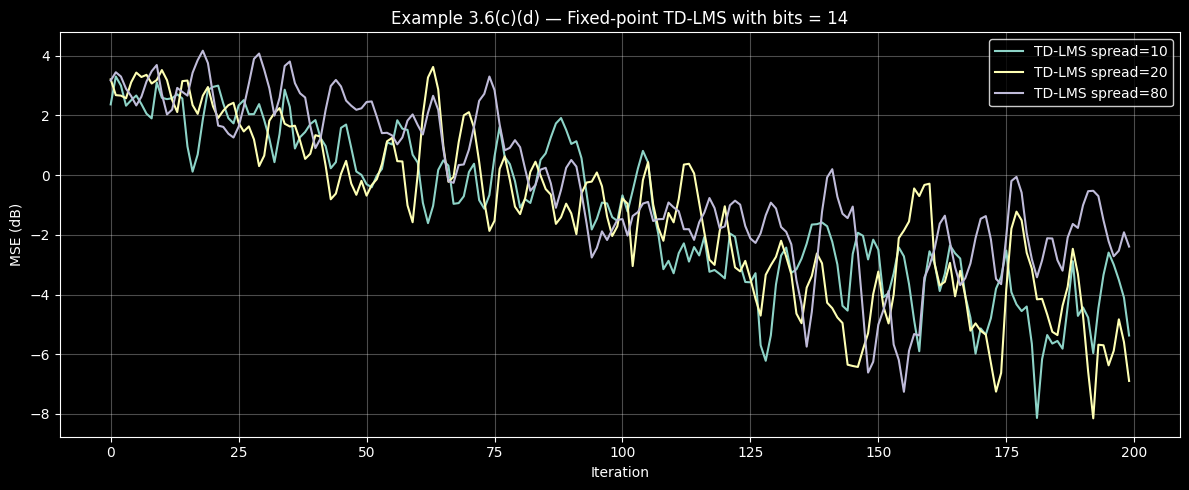

In [5]:
def trainSeqs_3_6cd(n_samples, a, sigma_x2=1.0, sigma_n2=0.0015):
  """
  AR(1) colored input, fixed system (Example 3.6(c)(d))
  """
  n_warmups = (int)(n_samples * 0.2)
  N = n_samples + n_warmups

  # variance-correct AR(1) innovation
  sigma_v2 = sigma_x2 * (1 - a*a)
  u = np.random.randn(N) * np.sqrt(sigma_v2)

  x = np.zeros(N)
  for k in range(1, N):
      x[k] = a * x[k-1] + u[k]

  h_true = np.array([0.1,0.3,0.0,-0.2,-0.4,-0.7,-0.4,-0.2])

  d = np.convolve(x, h_true, mode="full")[:N]
  d += np.random.randn(N) * np.sqrt(sigma_n2)

  return x[-n_samples:], d[-n_samples:], h_true

def runOneTrialTD(mu, bits, a, n_samples):
  x, d, h_true = trainSeqs_3_6cd(n_samples, a)
  w_hist, e_hist = fixedTransformedDomain(x, d, mu, bits)
  return w_hist, e_hist, h_true

def runEnsembleTD(mu, bits, a, n_samples, n_ens):
  mse_accum = np.zeros(n_samples)
  w_final = []

  for _ in range(n_ens):
    w_hist, e_hist, h_true = runOneTrialTD(mu, bits, a, n_samples)
    mse_accum += e_hist**2
    w_final.append(w_hist[-1])

  mse_avg = mse_accum / n_ens
  w_avg = np.mean(np.stack(w_final), axis=0)

  return mse_avg, w_avg, h_true

mu = 0.01
bit = 14
n_samples = 200
n_ens = 50

spreads = [10, 20, 80]

def ar1FromSpread(S):
  return (np.sqrt(S)-1)/(np.sqrt(S)+1)

plt.figure(figsize=(12,5))
print("\n=== FIXED POINT: {} bit ===".format(bit))
for S in spreads:
  a = ar1FromSpread(S)
  mse_avg, w_avg, _ = runEnsembleTD(mu, bit, a, n_samples, n_ens)
  plt.plot(10*np.log10(mse_avg+1e-12), label=f"TD-LMS spread={S}")

plt.title(f"Example 3.6(c)(d) — Fixed-point TD-LMS with bits = {bit}")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from adsp import jaxfilter, jaxfixedpt

def timeVaryingData3_6e(
    key,
    n_samples,
    h0,
    lambda_w=0.99,
    sigma_w2=0.0015,
    sigma_x2=1.0,
    sigma_n2=0.01,
    warmup=200,
):
    L = h0.shape[0]
    total = n_samples + warmup

    key, kx, ksys = jax.random.split(key, 3)

    # white input x(k) ~ N(0, sigma_x2)
    x_innov = jax.random.normal(kx, (total,), dtype=jnp.float32) * jnp.sqrt(sigma_x2)

    def step(carry, x_new):
      x_vec, h_prev, k = carry

      # shift register: x_vec[0] is current sample
      x_vec = jnp.concatenate([jnp.array([x_new], x_vec.dtype), x_vec[:-1]])

      # fresh q,n each iter
      k, kq, kn = jax.random.split(k, 3)
      q = jax.random.normal(kq, (L,), dtype=jnp.float32) * jnp.sqrt(sigma_w2)
      h = lambda_w * h_prev + q

      n = jax.random.normal(kn, (), dtype=jnp.float32) * jnp.sqrt(sigma_n2)
      d = jnp.dot(h, x_vec) + n

      return (x_vec, h, k), (h, x_new, d, n)

    x0 = jnp.zeros((L,), dtype=jnp.float32)
    carry0 = (x0, h0.astype(jnp.float32), ksys)

    (_, _, _), (h_hist, x_seq, d_seq, n_seq) = jax.lax.scan(step, carry0, x_innov)

    # drop warmup
    x = x_seq[warmup:warmup + n_samples]
    d = d_seq[warmup:warmup + n_samples]
    h = h_hist[warmup:warmup + n_samples]
    n = n_seq[warmup:warmup + n_samples]
    return x, d, h, n


# ------------------------------------------------------------
# 2) One run (one ensemble member)
# ------------------------------------------------------------
def runOnceTD(key, cfg):
    x, d, h_hist, n = timeVaryingData3_6e(
      key=key,
      n_samples=cfg["n_samples"],
      h0=cfg["h0"],
      lambda_w=cfg["lambda_w"],
      sigma_w2=cfg["sigma_w2"],
      sigma_x2=cfg["sigma_x2"],
      sigma_n2=cfg["sigma_n2"],
      warmup=cfg["warmup"],
    )

    model = jaxfilter.TransformDomain(
      mu=cfg["mu"],
      alpha=cfg["alpha"],
      gamma=cfg["gamma"],
      init_power=cfg["init_power"],
      matrix=cfg["matrix"],
      filter_order=cfg["N"],     # N = L-1
    )

    variables = model.init(key, x, d)
    (y_hist, e_hist, w_hist), _ = model.apply(
        variables, x, d, train=True, mutable=["state"]
    )

    # sanity checks
    assert e_hist.shape == (cfg["n_samples"],), e_hist.shape
    assert w_hist.shape == (cfg["n_samples"] + 1, cfg["N"] + 1), w_hist.shape

    return e_hist, w_hist, h_hist, n


# ------------------------------------------------------------
# 3) Small ensemble average (simple for-loop, no heavy vectorization)
# ------------------------------------------------------------
def runEnsTD(cfg):
    key = jax.random.PRNGKey(cfg["seed"])
    mse_accum = jnp.zeros((cfg["n_samples"],), dtype=jnp.float32)
    noise_accum = jnp.zeros((cfg["n_samples"],), dtype=jnp.float32)

    for _ in range(cfg["n_ens"]):
      key, sub = jax.random.split(key)
      e_hist, w_hist, h_hist, n = runOnceTD(sub, cfg)

      mse_accum += jnp.abs(e_hist) ** 2
      noise_accum += (n ** 2)

    mse_avg = mse_accum / cfg["n_ens"]
    noise_pow = noise_accum / cfg["n_ens"]
    return mse_avg, noise_pow


# ------------------------------------------------------------
# 4) Plot helper (dark/high contrast)
# ------------------------------------------------------------
def pltLearningCurve(mse_avg, noise_pow, title):
    plt.style.use("dark_background")
    plt.figure(figsize=(12, 5))
    plt.plot(10 * jnp.log10(mse_avg + 1e-12), linewidth=2.0, label="MSE (avg)")
    plt.plot(10 * jnp.log10(noise_pow + 1e-12), "-", linewidth=2.0, label="Noise power")
    plt.grid(True, alpha=0.25)
    plt.xlabel("Iteration")
    plt.ylabel("Power [dB]")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5) Minimal configuration + run
# ------------------------------------------------------------
h0 = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=jnp.float32)
N = h0.shape[0] - 1

cfg = dict(
    seed=0,
    n_samples=200,
    warmup=200,
    n_ens=50,            # <-- small ensemble (you asked)
    h0=h0,
    N=N,

    # system params
    lambda_w=0.99,
    sigma_w2=0.0015,
    sigma_x2=1.0,
    sigma_n2=0.01,

    # TD-LMS params
    matrix="dct",
    mu=0.05,
    alpha=0.05,
    gamma=1e-6,
    init_power=0.01,
)

mse_avg, noise_pow = runEnsTD(cfg)
pltLearningCurve(mse_avg, noise_pow, f"TD-LMS (DCT) — 3.6(e)  (μ={cfg['mu']}, ens={cfg['n_ens']})")

# steady-state metrics (last 100 samples)
tail = 100
mse_ss = float(jnp.mean(mse_avg[-tail:]))
noise_ss = float(jnp.mean(noise_pow[-tail:]))
excess = mse_ss - noise_ss
print("steady MSE =", mse_ss)
print("noise pow  =", noise_ss)
print("excess MSE =", excess)


6. Use the sign-error algorithm to identify a system with the transfer function given below. The input signal is a uniformly distributed white noise with variance $\sigma_x^2 = 1$, and the measurement noise is Gaussian white noise uncorrelated with the input with variance $\sigma_n^2 = 10^{-3}$. The adaptive filter has 12 coefficients.
   $$H(z) = \frac{1 - z^{-12}}{1 + z^{-1}}$$
   
(a) Calculate the upper bound for $\mu$ ($\mu_{\text{max}}$) to guarantee the algorithm stability.

(b) Run the algorithm for $\mu_{\text{max}}/2$, $\mu_{\text{max}}/5$, and $\mu_{\text{max}}/10$. Comment on the convergence behavior in each case.

(c) Measure the misadjustment in each example and compare with the results obtained by (4.28).

(d) Plot the obtained FIR filter frequency response at any iteration after convergence is achieved and compare with the unknown system.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

# -------------------------
# Problem setup (6)
# -------------------------
M = 12                       # 12 coefficients
sigma_x2 = 1.0
sigma_n2 = 1e-3
n_samples = 3000             # make it longer so "after convergence" is meaningful
n_ens = 200

# Calculate the upper bound for /mu to guarantee the algorithm stability.
R = sigma_x2 * np.eye(M)
min_mse  = sigma_n2
mu_max = (1/np.trace(R))*(np.sqrt(np.pi*min_mse/2))
print(mu_max)

0.0033027727480050093


Step 1: Algebraic ExpansionUtilizing geometric series / polynomial identities to expand the transfer function:$$\frac{1 - z^{-12}}{1 + z^{-1}} = 1 - z^{-1} + z^{-2} - z^{-3} + \dots + z^{-10} - z^{-11}$$$$H(z) = \sum_{n=0}^{11} (-1)^n z^{-n}$$Step 2: Correspondence to FIR Impulse ResponseBy definition of an FIR filter:$$H(z) = \sum_{n=0}^{M-1} h[n] z^{-n}$$The resulting coefficients are:$$h[n] = (-1)^n, \quad n = 0, \dots, 11$$

In [3]:
# True FIR: h[n] = (-1)^n, n=0..11
h_true = np.array([1 if (n % 2 == 0) else -1 for n in range(M)], dtype=np.float64)

mu_max = 0.08333333333333333
mu=0.041667  steady MSE=1.264626e-02  misadj_exp=11.6463
misadj_exp=19.816636488030053
mu=0.016667  steady MSE=3.467204e-03  misadj_exp=2.4672
misadj_exp=7.926654595212021
mu=0.008333  steady MSE=1.929727e-03  misadj_exp=0.9297
misadj_exp=3.9633272976060105


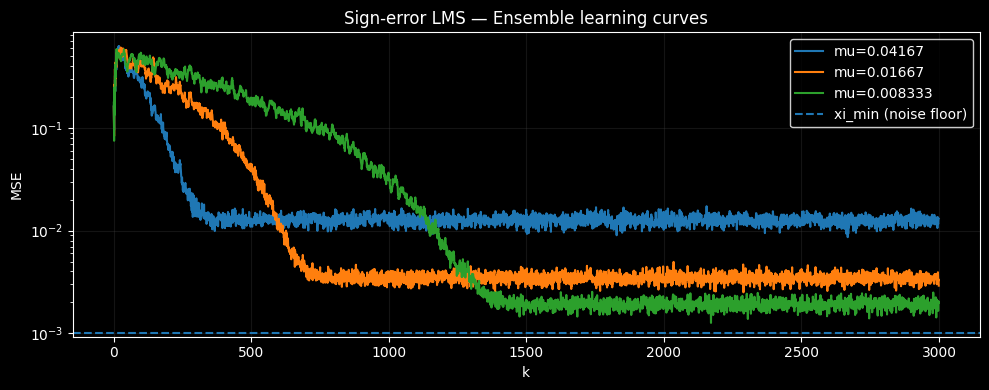

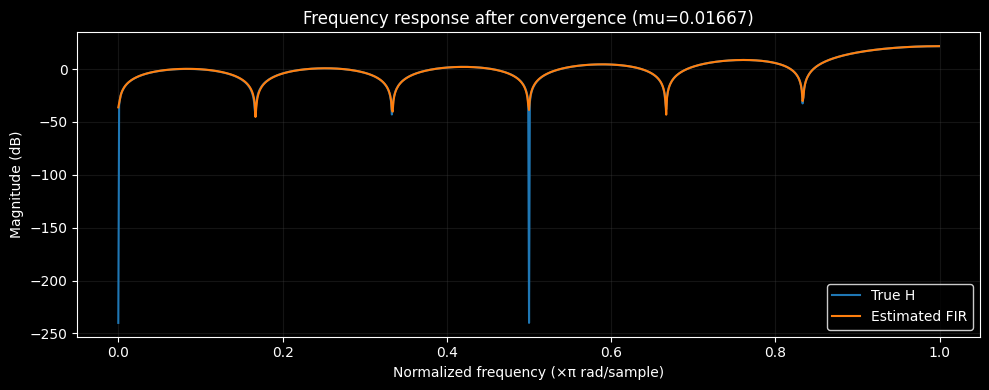

In [4]:
def dataFn_prob6(rng, n, sigma_x2=1.0, sigma_n2=1e-3):
    # uniform white noise with variance sigma_x2
    x = np.sqrt(sigma_x2 / 2)*(np.random.uniform(size=n))    
    # desired system output
    y_sys = np.convolve(x, h_true, mode="full")[:n]

    # measurement noise
    v = rng.normal(0.0, np.sqrt(sigma_n2), size=n).astype(np.float64)
    d = y_sys + v
    return x, d

def signErrLms(x, d, mu, M=12):
    n = len(x)
    w = np.zeros(M, dtype=np.float64)
    e = np.zeros(n, dtype=np.float64)

    x_pad = np.concatenate([np.zeros(M-1, dtype=np.float64), x])

    for k in range(n):
        reg = x_pad[k:k+M][::-1]     # [x(k), x(k-1), ..., x(k-M+1)]
        y = np.dot(w, reg)
        e[k] = d[k] - y

        s = np.sign(e[k])            # sign-error
        w = w + (2.0 * mu) * s * reg
    return e, w

# mu_max (for the "w += 2*mu*sign(e)*x" convention)
mu_max = 1.0 / (M * sigma_x2)
mus = [mu_max/2, mu_max/5, mu_max/10]

# -------------------------
# Ensemble learning curves
# -------------------------
mse_curves = {}
w_final = {}

for mu in mus:
    mse_acc = np.zeros(n_samples, dtype=np.float64)
    w_last_acc = np.zeros(M, dtype=np.float64)

    for i in range(n_ens):
        rng = np.random.default_rng(1000 + i)
        x, d = dataFn_prob6(rng, n_samples, sigma_x2, sigma_n2)

        e, w = signErrLms(x, d, mu, M=M)
        mse_acc += e**2
        w_last_acc += w

    mse_avg = mse_acc / n_ens
    w_avg = w_last_acc / n_ens

    mse_curves[mu] = mse_avg
    w_final[mu] = w_avg

# -------------------------
# Misadjustment estimate
# -------------------------
# For this identification problem, xi_min is measurement-noise floor only if the system is perfectly matched.
# But for sign-error, a safer "xi_min" is sigma_n2 (after perfect cancellation of system output).
# If you want pure EMSE-based misadjustment, use xi_min = sigma_n2.
xi_min = sigma_n2

def misadjustment(mse, tail=500):
    ss = np.mean(mse[-tail:])
    return (ss - xi_min) / xi_min
  
signErrMisadjTheor = lambda mu: mu*np.sqrt(np.pi/(2*min_mse))*np.trace(R)
print("mu_max =", mu_max)
for mu in mus:
    misadj_theor = signErrMisadjTheor(mu)
    print(f"mu={mu:.6f}  steady MSE={np.mean(mse_curves[mu][-500:]):.6e}  misadj_exp={misadjustment(mse_curves[mu]):.4f}")
    print(f"misadj_exp={misadj_theor}")
  
# -------------------------
# Plot learning curves
# -------------------------
plt.figure(figsize=(10,4))
for mu in mus:
    plt.semilogy(mse_curves[mu], label=f"mu={mu:.4g}")
plt.axhline(xi_min, linestyle="--", label="xi_min (noise floor)")
plt.grid(True, alpha=0.3)
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("Sign-error LMS — Ensemble learning curves")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Frequency response after convergence
# -------------------------
mu_pick = mus[1]  # e.g. mu_max/5
w_hat = w_final[mu_pick]

w1, H_true = freqz(h_true, worN=1024)
w2, H_hat  = freqz(w_hat,  worN=1024)

plt.figure(figsize=(10,4))
plt.plot(w1/np.pi, 20*np.log10(np.maximum(np.abs(H_true), 1e-12)), label="True H")
plt.plot(w2/np.pi, 20*np.log10(np.maximum(np.abs(H_hat),  1e-12)), label="Estimated FIR")
plt.grid(True, alpha=0.3)
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.title(f"Frequency response after convergence (mu={mu_pick:.4g})")
plt.legend()
plt.tight_layout()
plt.show()


8. Repeat Problem 6 when the input signal is a uniformly distributed white noise with variance $σ_n^2 = 0.5$, filtered by an
all-pole filter given by
$$H(z)=\frac{z}{z − 0.9}$$

tr(R)=31.578947
mu_max=1.25505364e-03 (Problem 8 trace-bound)
mu=6.275e-04  steady MSE=8.626661e-01  M_exp=861.6661  M_th=785.3982
mu=2.510e-04  steady MSE=1.397467e+00  M_exp=1396.4670  M_th=314.1593
mu=1.255e-04  steady MSE=1.650182e+00  M_exp=1649.1816  M_th=157.0796


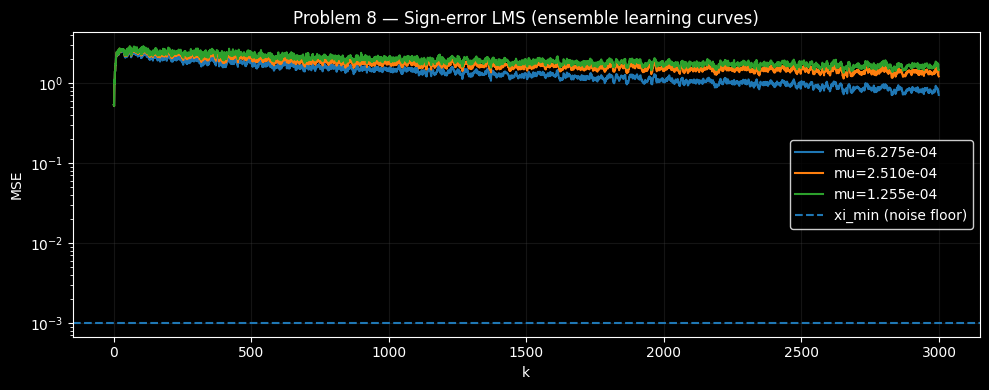

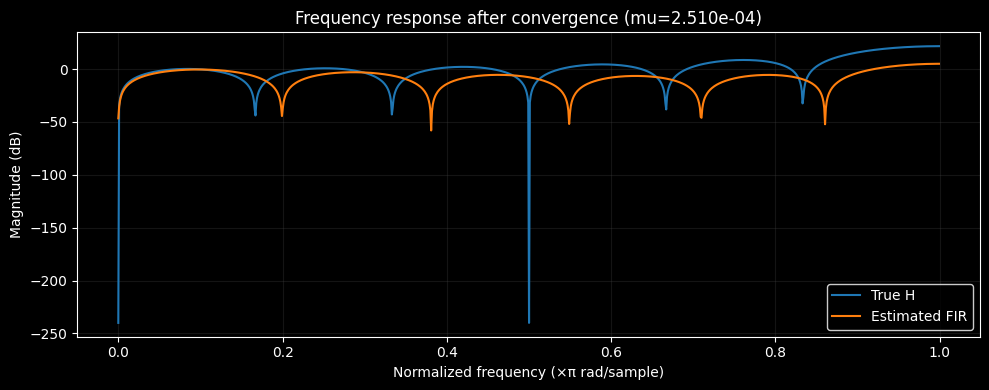

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz

# -------------------------
# Problem 8 setup
# -------------------------
M = 12
sigma_u2 = 0.5       # <-- Problem 8: raw uniform (excitation) variance
sigma_n2 = 1e-3      # measurement noise variance
a_ar = 0.9           # all-pole parameter
n_samples = 3000
n_ens = 500

# True FIR: h[n] = (-1)^n, n=0..11
h_true = (-1.0) ** np.arange(M)

# -------------------------
# Data generator (Problem 8)
# u -> AR(1) all-pole -> x -> unknown FIR -> + noise -> d
# -------------------------
def dataFn_prob8(rng, n, h_true, sigma_u2=0.5, sigma_n2=1e-3, a_ar=0.9):
  # 1) raw uniform white noise (normalize to exact sample variance = sigma_u2)
  u = rng.uniform(low=-1.0, high=1.0, size=n)
  u = u - np.mean(u)
  u = u / np.sqrt(np.var(u) + 1e-15) * np.sqrt(sigma_u2)

  # 2) all-pole filter: H(z) = z/(z-a)  => x[k] = a x[k-1] + u[k-1]
  b = [1.0, 0.0]
  a = [1.0, -a_ar]
  x = lfilter(b, a, u)

  # 3) unknown system (FIR)
  y_sys = np.convolve(x, h_true, mode="full")[:n]

  # 4) measurement noise
  v = rng.normal(0.0, np.sqrt(sigma_n2), size=n)
  d = y_sys + v
  return x, d

def signErrLms(x, d, mu, M=12):
  n = len(x)
  w = np.zeros(M, dtype=np.float64)
  e = np.zeros(n, dtype=np.float64)

  x_pad = np.concatenate([np.zeros(M-1, dtype=np.float64), x.astype(np.float64)])

  for k in range(n):
    reg = x_pad[k:k+M][::-1]      # [x(k), x(k-1), ..., x(k-M+1)]
    y = np.dot(w, reg)
    e_k = d[k] - y
    e[k] = e_k
    w = w + (2.0 * mu) * np.sign(e_k) * reg
  return e, w

# -------------------------
# Theoretical R for AR(1) input (approx)
# r_x[l] = (a^|l|) * sigma_u2 / (1-a^2)
# -------------------------
def r_x(l, sigma_u2, a_ar=0.9):
  return (a_ar ** abs(l)) * sigma_u2 / (1.0 - a_ar**2)

R = np.fromfunction(lambda i, j: r_x(i-j, sigma_u2, a_ar), (M, M), dtype=int)
trR = float(np.trace(R))

# Diniz sign-error practical bound (trace-form):
# 0 < mu < (1/tr(R)) * sqrt(pi*xi_min/2), with xi_min ~= sigma_n^2  :contentReference[oaicite:0]{index=0}
xi_min = sigma_n2
mu_max = (1.0 / trR) * np.sqrt(np.pi * xi_min / 2.0)

mus = [mu_max/2.0, mu_max/5.0, mu_max/10.0]

# -------------------------
# Misadjustment
# M = (xi_ss - xi_min)/xi_min
# -------------------------
def misadjustment(mse, xi_min, tail=500):
    tail = min(tail, len(mse))
    ss = float(np.mean(mse[-tail:]))
    return (ss - xi_min) / xi_min

# Theory (Eq. 4.28): M = mu * sqrt(pi/(2*xi_min)) * tr(R) / xi_min ?  (as coded in your style)
# In the chapter, misadjustment is proportional to mu * tr(R) / xi_min.  :contentReference[oaicite:1]{index=1}
def signErrMisadjTheor(mu, trR, xi_min):
    return mu * np.sqrt(np.pi/(2.0*xi_min)) * trR / xi_min

# -------------------------
# Ensemble learning curves
# -------------------------
mse_curves = {}
w_final = {}

print(f"tr(R)={trR:.6f}")
print(f"mu_max={mu_max:.8e} (Problem 8 trace-bound)")

for mu in mus:
    mse_acc = np.zeros(n_samples, dtype=np.float64)
    w_last_acc = np.zeros(M, dtype=np.float64)

    for i in range(n_ens):
        rng = np.random.default_rng(1000 + i)
        x, d = dataFn_prob8(rng, n_samples, h_true, sigma_u2=sigma_u2, sigma_n2=sigma_n2, a_ar=a_ar)
        e, w = signErrLms(x, d, mu, M=M)
        mse_acc += e**2
        w_last_acc += w

    mse_avg = mse_acc / n_ens
    w_avg = w_last_acc / n_ens

    mse_curves[mu] = mse_avg
    w_final[mu] = w_avg

# -------------------------
# Print misadjustment comparison
# -------------------------
for mu in mus:
    mse_ss = float(np.mean(mse_curves[mu][-500:]))
    m_exp = misadjustment(mse_curves[mu], xi_min=xi_min, tail=500)
    # If you want to compare strictly with Eq(4.28), use the same xi_min assumption.
    m_th  = signErrMisadjTheor(mu, trR=trR, xi_min=xi_min)
    print(f"mu={mu:.3e}  steady MSE={mse_ss:.6e}  M_exp={m_exp:.4f}  M_th={m_th:.4f}")

# -------------------------
# Plot learning curves
# -------------------------
plt.figure(figsize=(10,4))
for mu in mus:
    plt.semilogy(mse_curves[mu], label=f"mu={mu:.3e}")
plt.axhline(xi_min, linestyle="--", label="xi_min (noise floor)")
plt.grid(True, alpha=0.3)
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("Problem 8 — Sign-error LMS (ensemble learning curves)")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# Frequency response after convergence
# -------------------------
mu_pick = mus[1]  # mu_max/5
w_hat = w_final[mu_pick]

w1, H_true = freqz(h_true, worN=1024)
w2, H_hat  = freqz(w_hat,  worN=1024)

plt.figure(figsize=(10,4))
plt.plot(w1/np.pi, 20*np.log10(np.maximum(np.abs(H_true), 1e-12)), label="True H")
plt.plot(w2/np.pi, 20*np.log10(np.maximum(np.abs(H_hat),  1e-12)), label="Estimated FIR")
plt.grid(True, alpha=0.3)
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.title(f"Frequency response after convergence (mu={mu_pick:.3e})")
plt.legend()
plt.tight_layout()
plt.show()


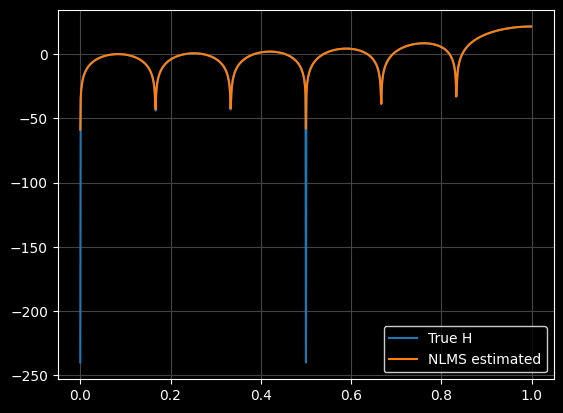

In [20]:
def nlms(x, d, mu_n, M=12, gamma=1e-3):
    n = len(x)
    w = np.zeros(M)
    e = np.zeros(n)

    x_pad = np.concatenate([np.zeros(M-1), x])

    for k in range(n):
        reg = x_pad[k:k+M][::-1]
        y = np.dot(w, reg)
        e[k] = d[k] - y

        norm = gamma + np.dot(reg, reg)
        w = w + mu_n * e[k] * reg / norm

    return e, w
mu_ns = [1.0, 0.5, 0.2]
gamma = 1e-3

mse_curves_nlms = {}
w_final_nlms = {}

for mu_n in mu_ns:
    mse_acc = np.zeros(n_samples)
    w_acc = np.zeros(M)

    for i in range(n_ens):
        rng = np.random.default_rng(2000 + i)
        x, d = dataFn_prob8(
            rng, n_samples, h_true,
            sigma_u2=sigma_u2,
            sigma_n2=sigma_n2,
            a_ar=a_ar
        )

        e, w = nlms(x, d, mu_n, M=M, gamma=gamma)
        mse_acc += e**2
        w_acc += w

    mse_curves_nlms[mu_n] = mse_acc / n_ens
    w_final_nlms[mu_n] = w_acc / n_ens
mu_pick = 0.5
w_hat = w_final_nlms[mu_pick]

w1, H_true = freqz(h_true, worN=1024)
w2, H_hat  = freqz(w_hat,  worN=1024)

plt.plot(w1/np.pi, 20*np.log10(np.abs(H_true)+1e-12), label="True H")
plt.plot(w2/np.pi, 20*np.log10(np.abs(H_hat)+1e-12), label="NLMS estimated")
plt.legend()
plt.grid(True)
plt.show()
